# Exercise 1: Autonomous vehicle route planning (Waymo, San Francisco)

Starter notebook for **Exercise 1** from the chapter *LLMs as planners: Reasoning instead of programming*.

We compare two approaches to route planning on a 20×20 city grid:

- **Approach A (classical):** A* on a weighted grid — a geometrically optimal route.
- **Approach B (hybrid):** an LLM simulator (*if/else* rules) modifies grid weights based on context, and then A* recalculates the route.

Scene: start *Market St* (0,0), goal *Mission Bay* (19,19). Cell = 20 m. Environment: closed streets (hard obstacles), traffic jams (weight ×10), residential zones (normal streets, weight 1.0 — avoided only by the "social" planner).

In [1]:
import numpy as np
import heapq
import time
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

np.random.seed(42)  # repeatability of results

GRID = 20                 # 20 x 20 grid
START = (0, 0)            # Market St (row, column)
GOAL = (19, 19)           # Mission Bay
CELL_M = 20               # 1 cell = 20 m

# Weight matrix: cost of entering a cell (1.0 = normal street)
W = np.ones((GRID, GRID), dtype=float)

# Traffic jams (weight x10) - central congestion area
traffic_jams = [(r, c) for r in range(4, 8) for c in range(7, 13)]
for (r, c) in traffic_jams:
    W[r, c] = 10.0

# Residential zone: these are normal streets (weight 1) on the shortest approach to the goal.
# Classical A* eagerly cuts through them; only the "social" planner (LLM) avoids them
# for non-geometric reasons (children, quiet) — see the challenge cell.
residential = [(r, c) for r in range(12, 18) for c in range(16, 20)]
residential_set = set(residential)
for (r, c) in residential:
    W[r, c] = 1.0

# Closed streets forming a maze: horizontal wall (row 10) + vertical fragment (column 15).
# Forces a crossing either far left (col 0-1) or right (col 14, 16-19).
closed_streets = [(10, c) for c in range(2, 14)] + [(r, 15) for r in range(2, 12)]
for (r, c) in closed_streets:
    W[r, c] = np.inf

print('Environment ready. Start =', START, ' Goal =', GOAL)
print('Traffic jams:', len(traffic_jams), '| residential:', len(residential), '| closed:', len(closed_streets))

Environment ready. Start = (0, 0)  Goal = (19, 19)
Traffic jams: 24 | residential: 24 | closed: 22


## Approach A (classical): A* on a weighted grid

We implement the **A\*** algorithm (4-connected) ourselves. The cost of entering a cell is its weight `W[cell]`,
and the heuristic is the Manhattan distance (admissible because minimum weight = 1, so it never overestimates).

> The chapter mentioned the `pathfinding` library; here, for full transparency and zero dependencies,
> we use our own ~30-line A\* implementation.

In [2]:
def astar(weight_grid, start, goal):
    """A* on a weighted grid (4-connected).

    Cost to enter cell = weight_grid[cell]; obstacles have weight inf.
    Returns: (path, total_cost, num_expanded_nodes, time_ms).
    """
    n_rows, n_cols = weight_grid.shape

    def h(a, b):  # Manhattan heuristic
        return abs(a[0] - b[0]) + abs(a[1] - b[1])

    t0 = time.perf_counter()
    open_heap = [(h(start, goal), 0.0, start)]
    g = {start: 0.0}
    parent = {start: None}
    closed = set()
    expanded = 0

    while open_heap:
        _, gc, node = heapq.heappop(open_heap)
        if node in closed:
            continue
        closed.add(node)
        expanded += 1
        if node == goal:
            break
        r, c = node
        for dr, dc in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
            nr, nc = r + dr, c + dc
            if 0 <= nr < n_rows and 0 <= nc < n_cols:
                w = weight_grid[nr, nc]
                if not np.isfinite(w):      # hard obstacle
                    continue
                nb = (nr, nc)
                ng = gc + w
                if ng < g.get(nb, np.inf):
                    g[nb] = ng
                    parent[nb] = node
                    heapq.heappush(open_heap, (ng + h(nb, goal), ng, nb))

    dt_ms = (time.perf_counter() - t0) * 1000.0
    if goal not in parent:
        return None, np.inf, expanded, dt_ms

    path = []
    cur = goal
    while cur is not None:
        path.append(cur)
        cur = parent[cur]
    path.reverse()
    return path, g[goal], expanded, dt_ms


path_A, cost_A, exp_A, ms_A = astar(W, START, GOAL)
print(f'A* (classical): length = {len(path_A)} steps, cost = {cost_A:.1f}, '
      f'expanded nodes = {exp_A}, time = {ms_A:.2f} ms')

A* (classical): length = 39 steps, cost = 38.0, expanded nodes = 354, time = 2.26 ms


## Approach B (hybrid): LLM simulator

The `simulate_llm` function is an **LLM reasoning simulator** based on `if/else` rules (without API calls).
It receives a textual description of the situation and returns a decision: the zone on the grid whose cost should be increased
(e.g., *gas leak → take a wide detour*). We apply the decision to a copy of the weight matrix, after which
**A\* recalculates** the route on the updated map — this is the essence of the hybrid architecture from the chapter.

In [3]:
def simulate_llm(context, weight_grid):
    """LLM reasoning simulator (if/else rules imitating a language model).

    Based on a textual context, it returns a decision: justification + zone
    for weight modification (center, Manhattan radius, new weight).
    """
    ctx = context.lower()
    decision = {'justification': '', 'zone': None, 'radius': 0, 'weight': 1.0}

    if 'leak' in ctx and 'gas' in ctx:
        # Block the right corridor (default A* route) to force a detour.
        decision.update(justification='Gas leak -> close right corridor and take a detour.',
                       zone=(11, 14), radius=2, weight=1000.0)
    elif 'children' in ctx or 'school' in ctx:
        # Social preferences: hard exclusion of residential zone near goal.
        decision.update(justification='Children nearby -> strictly avoid residential zone.',
                       zone=(14, 17), radius=4, weight=1000.0)
    elif 'rain' in ctx or 'jam' in ctx:
        decision.update(justification='Rain/jams -> increase cost of congested streets.',
                       zone=(6, 12), radius=4, weight=25.0)
    else:
        decision.update(justification='No special hazards -> route unchanged.')
    return decision


def apply_decision(weight_grid, decision):
    """Returns a COPY of the grid with applied cost zone from LLM decision."""
    W2 = weight_grid.copy()
    if decision['zone'] is None:
        return W2
    cr, cc = decision['zone']
    rad, w = decision['radius'], decision['weight']
    for r in range(max(0, cr - rad), min(W2.shape[0], cr + rad + 1)):
        for c in range(max(0, cc - rad), min(W2.shape[1], cc + rad + 1)):
            if np.isfinite(W2[r, c]) and abs(r - cr) + abs(c - cc) <= rad:
                if w >= 999.0:
                    W2[r, c] = np.inf
                else:
                    W2[r, c] = max(W2[r, c], w)
    return W2


context = 'Warning: gas leak in the center, rain, children coming back from school.'
decision = simulate_llm(context, W)
print('Context:', context)
print('LLM Decision:', decision['justification'])

W_hybrid = apply_decision(W, decision)
path_B, cost_B, exp_B, ms_B = astar(W_hybrid, START, GOAL)
print(f'A* (hybrid): length = {len(path_B)} steps, cost = {cost_B:.1f}, '
      f'expanded nodes = {exp_B}, time = {ms_B:.2f} ms')

Context: Warning: gas leak in the center, rain, children coming back from school.
LLM Decision: Gas leak -> close right corridor and take a detour.
A* (hybrid): length = 39 steps, cost = 38.0, expanded nodes = 341, time = 2.05 ms


## Route visualization

City grid with both routes marked: **red** = classical A\*, **blue** = hybrid (LLM).
Background: normal streets (light), residential zones (yellow), traffic jams (orange), closed streets (black),
zone indicated by LLM (red background).

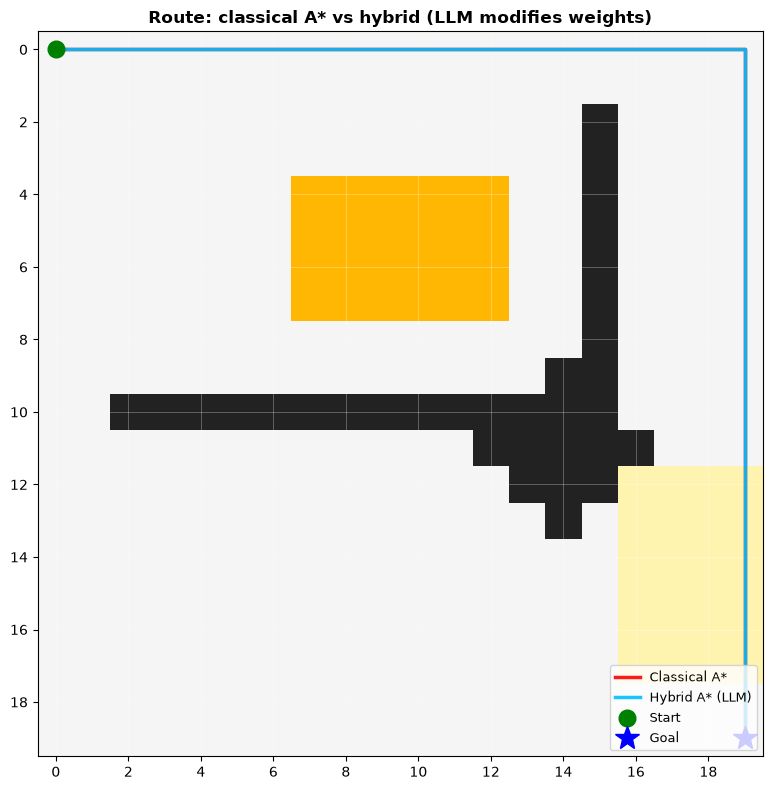

In [4]:
def categorize(weight_grid):
    """Maps weights to categories 0..4 for visualization."""
    disp = np.zeros_like(weight_grid)
    for (r, c) in residential:                                        # residential (normal streets)
        if np.isfinite(weight_grid[r, c]):
            disp[r, c] = 1
    disp[weight_grid == 10.0] = 2                                 # jam
    disp[(weight_grid > 10.0) & np.isfinite(weight_grid)] = 3     # LLM zone
    disp[~np.isfinite(weight_grid)] = 4                           # obstacle
    return disp


def plot_routes(weight_grid, routes, title):
    """routes: list of (path, color, label)."""
    fig, ax = plt.subplots(figsize=(8, 8))
    cmap = ListedColormap(['#f5f5f5', '#fff3b0', '#ffb703', '#ff6b6b', '#222222'])
    ax.imshow(categorize(weight_grid), cmap=cmap, vmin=0, vmax=4, origin='upper')

    for path, color, label in routes:
        if path:
            ys = [p[0] for p in path]
            xs = [p[1] for p in path]
            ax.plot(xs, ys, color=color, linewidth=2.5, label=label, alpha=0.9)

    ax.plot(START[1], START[0], 'o', color='green', markersize=12, label='Start')
    ax.plot(GOAL[1], GOAL[0], '*', color='blue', markersize=18, label='Goal')
    ax.set_xticks(range(0, GRID, 2))
    ax.set_yticks(range(0, GRID, 2))
    ax.grid(True, color='white', linewidth=0.5, alpha=0.4)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(loc='lower right', fontsize=9)
    plt.tight_layout()
    plt.show()


plot_routes(W_hybrid,
            [(path_A, 'red', 'Classical A*'),
             (path_B, 'deepskyblue', 'Hybrid A* (LLM)')],
            'Route: classical A* vs hybrid (LLM modifies weights)')

## Adaptation test: sudden street closure

After driving 5 steps, a street segment ahead of the vehicle is suddenly closed. A\* **recalculates the route**
from the current position — an illustration of closed-loop planning (replanning), crucial in dynamic traffic.

Position after 5 steps: (0, 5)
Randomly closed cells: [(0, 7), (1, 7), (1, 5)]
A* replanning from (0, 5): length = 34, cost = 33.0, time = 0.69 ms


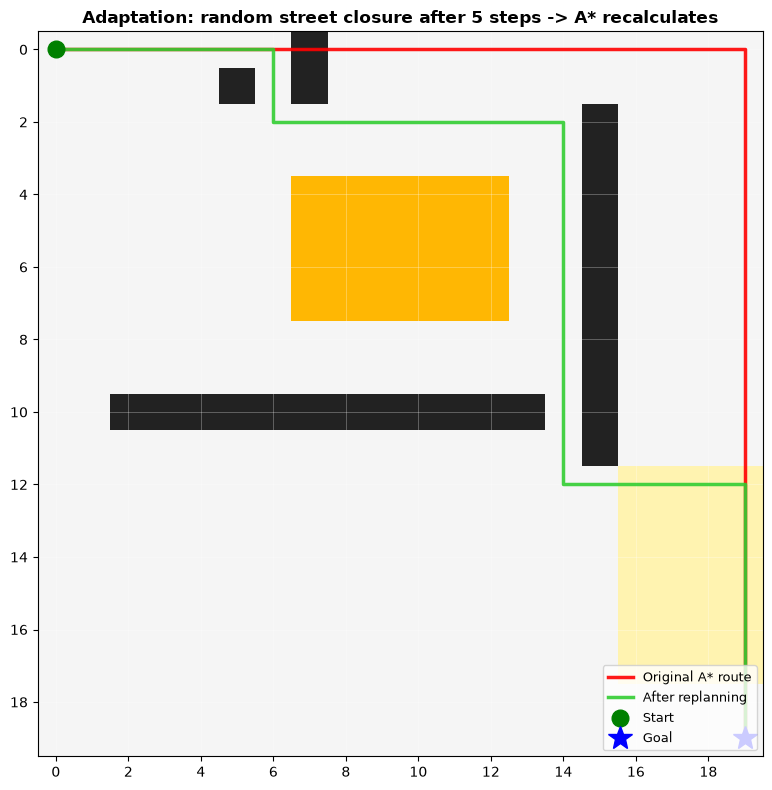

In [5]:
step = 5
position = path_A[step]
print(f'Position after {step} steps: {position}')

# Randomly close a street segment around the vehicle
W_closed = W.copy()
candidates = []
for dr in [-1, 0, 1]:
    for dc in [0, 1, 2]:
        r, c = position[0] + dr, position[1] + dc
        if (r, c) != position and 0 <= r < GRID and 0 <= c < GRID and np.isfinite(W_closed[r, c]):
            candidates.append((r, c))

# Draw 3 cells and close them as a new obstacle
np.random.seed(42)
idx = np.random.choice(len(candidates), size=min(3, len(candidates)), replace=False)
new_block = [candidates[i] for i in idx]
for (r, c) in new_block:
    W_closed[r, c] = np.inf

print('Randomly closed cells:', new_block)

# A* recalculates the route from the current position to the goal
path_re, cost_re, exp_re, ms_re = astar(W_closed, position, GOAL)
print(f'A* replanning from {position}: length = {len(path_re)}, cost = {cost_re:.1f}, time = {ms_re:.2f} ms')

adaptive_route = path_A[:step] + path_re
plot_routes(W_closed,
            [(path_A, 'red', 'Original A* route'),
             (adaptive_route, 'limegreen', 'After replanning')],
            f'Adaptation: random street closure after {step} steps -> A* recalculates')

## Metrics and comparison

We compare the path length (steps), total cost, number of expanded nodes and computation time
for both approaches.

In [6]:
print('=' * 56)
print('METRICS COMPARISON')
print('=' * 56)
print('Metric'.ljust(28) + 'Classical A*'.rjust(13) + 'LLM Hybrid'.rjust(15))
print('-' * 56)
print('Path length (steps)'.ljust(28) + str(len(path_A)).rjust(13) + str(len(path_B)).rjust(15))
print('Total cost'.ljust(28) + f'{cost_A:.1f}'.rjust(13) + f'{cost_B:.1f}'.rjust(15))
print('Expanded nodes'.ljust(28) + str(exp_A).rjust(13) + str(exp_B).rjust(15))
print('Computation time [ms]'.ljust(28) + f'{ms_A:.2f}'.rjust(13) + f'{ms_B:.2f}'.rjust(15))
print('=' * 56)
print('Conclusion: A* minimizes geometric cost; hybrid avoids zones')
print('indicated by LLM (e.g., gas leak) usually at the expense of a longer route.')

METRICS COMPARISON
Metric                       Classical A*     LLM Hybrid
--------------------------------------------------------
Path length (steps)                    39             39
Total cost                           38.0           38.0
Expanded nodes                        354            341
Computation time [ms]                2.26           2.05
Conclusion: A* minimizes geometric cost; hybrid avoids zones
indicated by LLM (e.g., gas leak) usually at the expense of a longer route.


## Challenge: social preferences

Extend the LLM simulator so that for a context containing, e.g., *school* / *children*, the route **avoids
the residential zone**, even if it is geometrically longer. Then compare both routes side by side.

Hint — a ready starter is provided below; run it and analyze the difference in length and cost
relative to the classical route.

LLM Decision: Children nearby -> strictly avoid residential zone.
Classical route: length = 39 steps, residential cells on route = 6
Social route: length = 39 steps, residential cells on route = 0
Social cost: +0 steps for limiting residential intrusions from 6 to 0


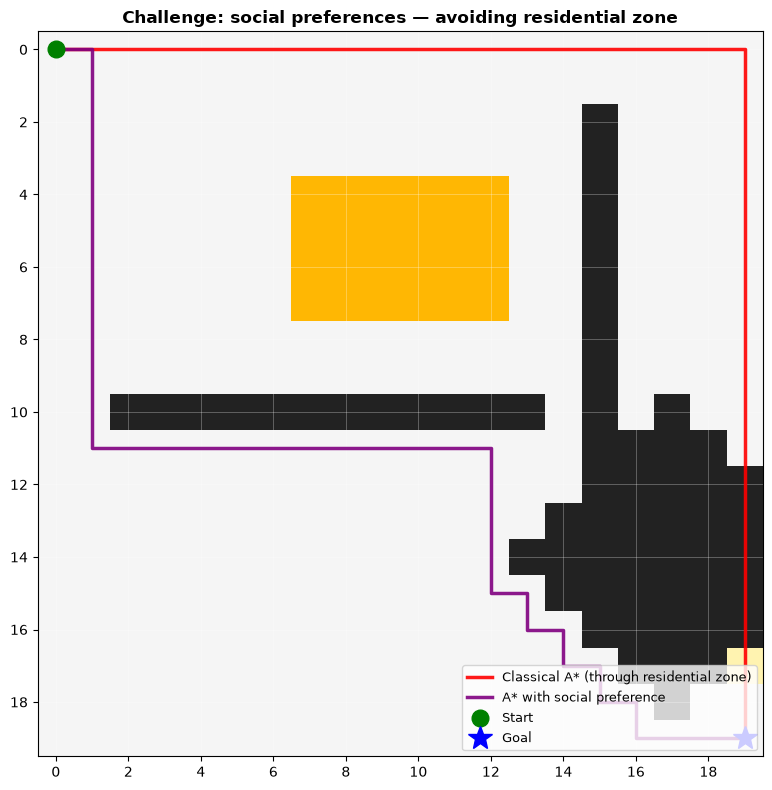

In [7]:
# Challenge starter: route with social preference (avoiding residential zone)
context_school = '3 PM: children returning from school near the residential zone.'
social_decision = simulate_llm(context_school, W)
print('LLM Decision:', social_decision['justification'])

# Classical A* treats residential zone as a normal street and eagerly cuts through.
# Social planner (LLM) blocks the residential zone -> A* replans a consistent route around it.
W_social = apply_decision(W, social_decision)
path_social, cost_social, exp_social, ms_social = astar(W_social, START, GOAL)

# Fair measure of "social preference": number of residential cells on the route.
def residential_cells(path):
    return sum(1 for cell in path if cell in residential_set)

intrusions_A = residential_cells(path_A)
intrusions_social = residential_cells(path_social)

print(f'Classical route: length = {len(path_A)} steps, residential cells on route = {intrusions_A}')
print(f'Social route: length = {len(path_social)} steps, residential cells on route = {intrusions_social}')
print(f'Social cost: {len(path_social) - len(path_A):+d} steps for limiting residential intrusions '
      f'from {intrusions_A} to {intrusions_social}')

plot_routes(W_social,
            [(path_A, 'red', 'Classical A* (through residential zone)'),
             (path_social, 'purple', 'A* with social preference')],
            'Challenge: social preferences — avoiding residential zone')